In [1]:
pip install polars

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.4/38.4 MB 113.8 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 15.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 158.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.2/355.2 kB 153.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 267.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 306.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 197.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 189.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.1/111.1 kB 66.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
import polars as pl

In [8]:
formats = [720,1080,2160]


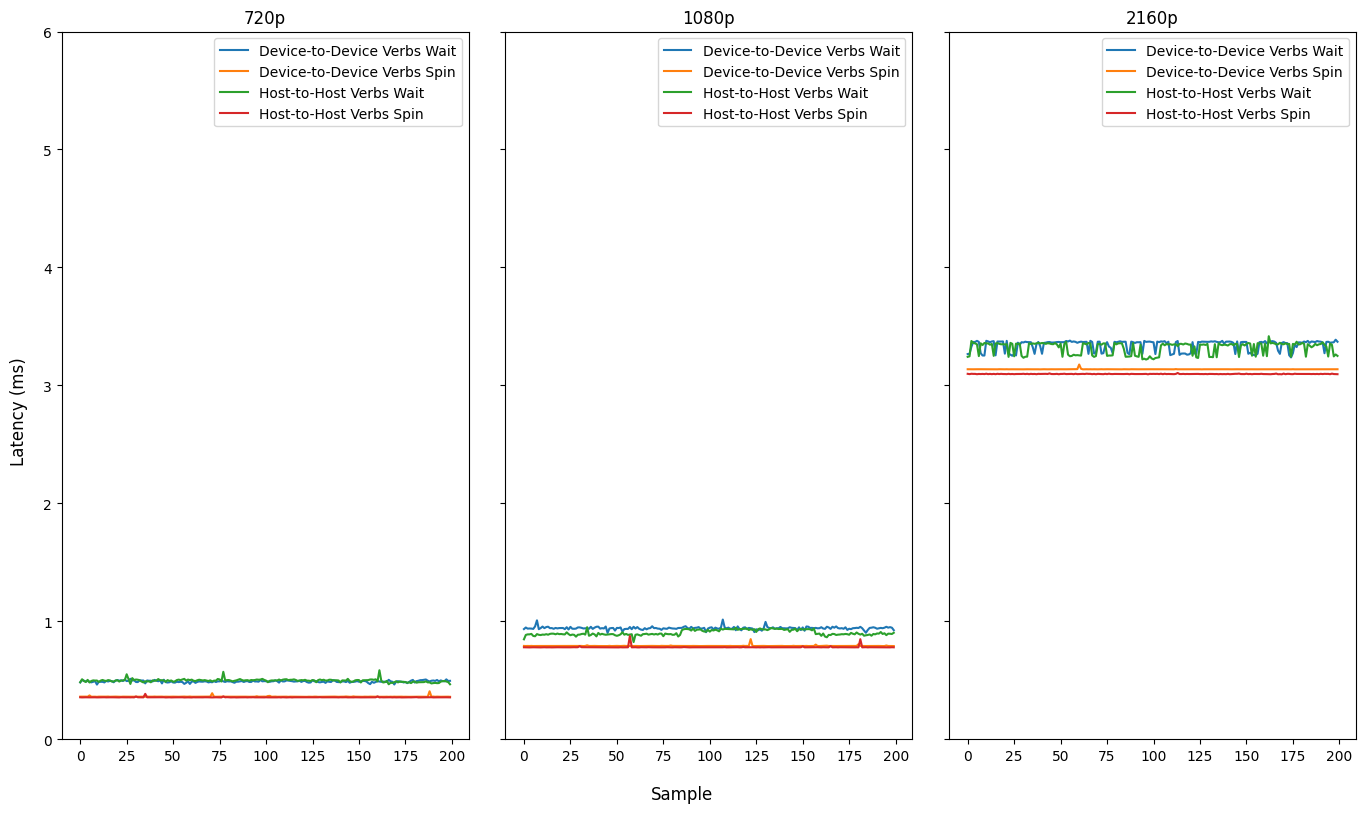

In [27]:
import matplotlib.pyplot as plt

data_h2h_wait = {}
data_h2h_spin = {}
data_d2d_wait = {}
data_d2d_spin = {}
for img_size in formats:
    data_d2d_wait[img_size] = pl.read_csv(f"../data/verbs/gpu-max-clock/{img_size}/MXLFabrics+Cuda2Cuda+Verbs+Reflect+Wait.csv").select(pl.col("Timers"))
    data_d2d_spin[img_size] = pl.read_csv(f"../data/verbs/gpu-max-clock/{img_size}/MXLFabrics+Cuda2Cuda+Verbs+Reflect+Spin.csv").select(pl.col("Timers"))
    data_h2h_wait[img_size] = pl.read_csv(f"../data/verbs/gpu-max-clock/{img_size}/MXLFabrics+Host2Host+Verbs+Reflect+Wait.csv").select(pl.col("Timers"))
    data_h2h_spin[img_size] = pl.read_csv(f"../data/verbs/gpu-max-clock/{img_size}/MXLFabrics+Host2Host+Verbs+Reflect+Spin.csv").select(pl.col("Timers"))
    
plt.rcParams['figure.figsize'] = [14,8]
fig, axs = plt.subplots(nrows=1,ncols=len(formats), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")

fig.tight_layout()

for i, img_size in enumerate(formats):
    axs[i].set_title(f"{img_size}p")
    axs[i].set_ylim(0,6)
    axs[i].plot(data_d2d_wait[img_size]/1e6/2, label=f"Device-to-Device Verbs Wait")
    axs[i].plot(data_d2d_spin[img_size]/1e6/2, label=f"Device-to-Device Verbs Spin")
    axs[i].plot(data_h2h_wait[img_size]/1e6/2, label=f"Host-to-Host Verbs Wait")
    axs[i].plot(data_h2h_spin[img_size]/1e6/2, label=f"Host-to-Host Verbs Spin")
    axs[i].legend()

